## CIFAR-100 image visualization(Canadian Institute for Advanced Research)

CIFAR-100 dataset already extracted to data/cifar-100-python


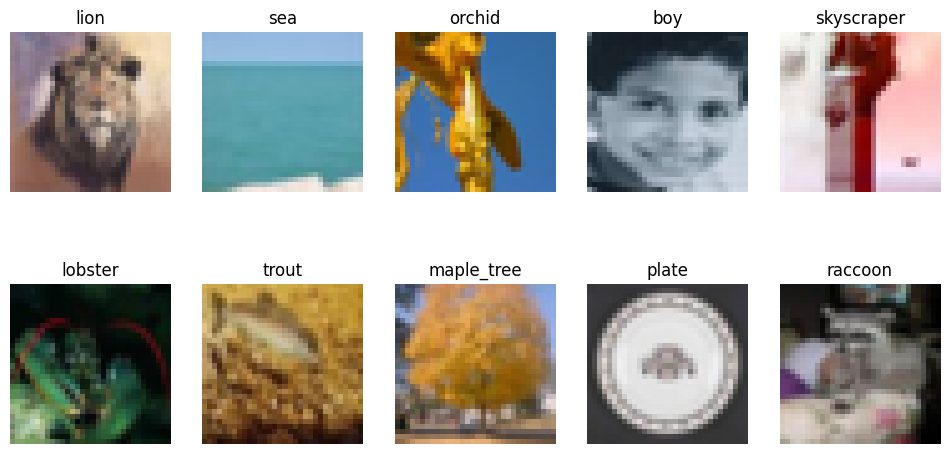

In [1]:
import os
import tarfile
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Correct path to your CIFAR-100 tarball file
tarball_path = "data/cifar-100-python.tar.gz"
extract_path = "data/cifar-100-python"

# Step 1: Extract the CIFAR-100 tarball
def extract_cifar100(tarball_path, extract_path):
    if not os.path.exists(extract_path):
        with tarfile.open(tarball_path, 'r:gz') as tar:
            tar.extractall(path=extract_path)
        print(f'CIFAR-100 dataset extracted to {extract_path}')
    else:
        print(f'CIFAR-100 dataset already extracted to {extract_path}')

# Step 2: Load CIFAR-100 batch (train or test)
def load_cifar100_batch(filename):
    """Load a batch from the CIFAR-100 dataset"""
    with open(filename, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    return batch

# Step 3: Load the CIFAR-100 dataset (train, test, and meta)
def load_cifar100_data(extract_path):
    # Paths to CIFAR-100 files (correct paths according to your directory structure)
    train_path = os.path.join(extract_path, 'train')
    test_path = os.path.join(extract_path, 'test')
    meta_path = os.path.join(extract_path, 'meta')

    # Load meta data to get class labels
    with open(meta_path, 'rb') as f:
        meta_data = pickle.load(f, encoding='bytes')
        class_names = [name.decode('utf-8') for name in meta_data[b'fine_label_names']]  # Decode byte strings

    # Load train and test data
    train_data = load_cifar100_batch(train_path)
    test_data = load_cifar100_batch(test_path)

    return train_data, test_data, class_names

# Step 4: Convert image from flat array to 32x32x3 and unnormalize
def unnormalize_image(img):
    """Convert CIFAR image from channel-first uint8/flat to HWC float [0,1]."""
    # Ensure numeric type then scale from [0,255] -> [0,1]
    img = img.astype(np.float32) / 255.0
    # Change shape from (C, H, W) to (H, W, C) for matplotlib
    return np.transpose(img, (1, 2, 0))

# Step 5: Visualize multiple random images from the CIFAR-100 dataset
def visualize_random_images(data, class_names, num_images=10):
    """Visualize random images from the CIFAR-100 dataset"""
    # Randomly select 10 images and their labels
    indices = random.sample(range(len(data[b'data'])), num_images)
    
    # Create a figure for plotting (2 rows, 5 columns)
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    
    for i, idx in enumerate(indices):
        image = data[b'data'][idx]
        label = data[b'fine_labels'][idx]
        
        # Convert the image from flat array to 32x32x3
        image = image.reshape(3, 32, 32)
        
        # Get the row and column for the grid
        row = i // 5
        col = i % 5
        
        # Plot the image
        ax = axes[row, col]
        ax.imshow(unnormalize_image(image))  # Unnormalize and plot
        ax.set_title(class_names[label])  # Display the label
        ax.axis('off')  # Hide axes

    plt.show()

# Main function to extract and visualize CIFAR-100 images
def main():
    # Step 1: Extract the CIFAR-100 dataset (only once)
    extract_cifar100(tarball_path, extract_path)

    # Step 2: Load CIFAR-100 data (train, test, and meta)
    train_data, test_data, class_names = load_cifar100_data(extract_path)

    # Step 3: Visualize one random image from the training set
    visualize_random_images(train_data, class_names)

# Run the main function
if __name__ == '__main__':
    main()
